In [1]:
import sys
import os
import xarray as xr
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Importing file paths from utils 
CODE_DIR = os.path.abspath(os.path.join(".."))  # points to 'code' folder
sys.path.append(CODE_DIR)
from y_utils import config

In [2]:
# Get path to ERA5 .grib file for 1979
era5_path_1979 = config.get_era5_raw_yearly(1979)

# Open the GRIB file using xarray and cfgrib engine
ds = xr.open_dataset(era5_path_1979, engine="cfgrib")

# Print summary
print(ds)


<xarray.Dataset> Size: 36GB
Dimensions:     (time: 8760, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 70kB 1979-01-01 ... 1979-12-31T23:00:00
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    valid_time  (time) datetime64[ns] 70kB ...
Data variables:
    t2m         (time, latitude, longitude) float32 36GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-16T10:37 GRIB to CDM+CF via cfgrib-0.9.1...


/global/home/users/yougsanghvi/global_suicide_dummy/climate-env/lib64/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


In [9]:
gdf

,ID_1,ID_2,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,ID_0,geometry
0,01,001,00161526,01001,Autauga,Autauga County,06,H1,G4020,None,33860,None,A,1539609015,25749942,+32.5322367,-086.6464395,244,"POLYGON ((-86.9031 32.54063, -86.90313 32.5410..."
1,01,003,00161527,01003,Baldwin,Baldwin County,06,H1,G4020,380,19300,None,A,4117584019,1133130502,+30.6592183,-087.7460666,244,"POLYGON ((-87.99068 30.55549, -87.99051 30.560..."
2,01,005,00161528,01005,Barbour,Barbour County,06,H1,G4020,None,21640,None,A,2291818680,50864677,+31.8702531,-085.4051035,244,"POLYGON ((-85.42982 32.04598, -85.42985 32.046..."
3,01,007,00161529,01007,Bibb,Bibb County,06,H1,G4020,142,13820,None,A,1612481559,9287974,+33.0158929,-087.1271475,244,"POLYGON ((-87.31226 33.08622, -87.31218 33.087..."
4,01,009,00161530,01009,Blount,Blount County,06,H1,G4020,142,13820,None,A,1670041875,15077458,+33.9773575,-086.5664400,244,"POLYGON ((-86.74919 33.9976, -86.74902 33.9975..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3223,72,151,01804556,72151,Yabucoa,Yabucoa Municipio,13,H1,G4020,490,41980,None,A,143005178,72592521,+18.0598584,-065.8598713,244,"POLYGON ((-65.94291 18.08924, -65.94273 18.089..."
3224,72,153,01804557,72153,Yauco,Yauco Municipio,13,H1,G4020,434,38660,None,A,175371915,1625260,+18.0856688,-066.8579009,244,"POLYGON ((-66.91602 18.09602, -66.91601 18.096..."
3225,78,010,02378248,78010,St. Croix,St. Croix Island,10,H4,G4020,None,None,None,N,215914994,645644841,+17.7352317,-064.7466437,244,"POLYGON ((-64.95318 17.66102, -64.95503 17.666..."
3226,78,020,02378249,78020,St. John,St. John Island,10,H4,G4020,None,None,None,N,50996518,186671948,+18.3304347,-064.7352610,244,"POLYGON ((-64.84372 18.35599, -64.84372 18.356..."


In [2]:


# Load US county shapefile
shapefile_path = "/global/scratch/users/yougsanghvi/shapefiles/tl_2016_us_county_mortality.shp"
gdf = gpd.read_file(shapefile_path)

# Filter for Shasta County, CA (FIPS: 06089)
shasta = gdf[(gdf["ID_1"] == "06") & (gdf["NAME"].str.lower() == "shasta")]

# Get centroid of the county
centroid = shasta.geometry.centroid.iloc[0]
centroid_lon = centroid.x
centroid_lat = centroid.y

# Convert lon to ERA5 format (0 to 360)
era5_lon = centroid_lon if centroid_lon >= 0 else 360 + centroid_lon

# Snap to nearest ERA5 grid (0.25° resolution)
def snap_to_grid(value, step=0.25):
    return round(value / step) * step

era5_grid_lat = snap_to_grid(centroid_lat)
era5_grid_lon = snap_to_grid(era5_lon)

# Print results
print("Shasta County centroid:")
print(f"  Latitude:  {centroid_lat}")
print(f"  Longitude: {centroid_lon} (ERA5: {era5_lon})")

print("\nNearest ERA5 grid cell:")
print(f"  Latitude:  {era5_grid_lat}")
print(f"  Longitude: {era5_grid_lon}")


Shasta County centroid:
  Latitude:  40.763766597053916
  Longitude: -122.0405215247329 (ERA5: 237.9594784752671)

Nearest ERA5 grid cell:
  Latitude:  40.75
  Longitude: 238.0


/tmp/ipykernel_793730/3094928957.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = shasta.geometry.centroid.iloc[0]


In [4]:
import xarray as xr

# Pick one of your GDNAT Zarr files to check
gdnat_path = f"{config.GDNAT_ZARR_DIR}/gdnat_ACCESS-CM2_tas_1979-1999_v2025-02-11.zarr"

# Open dataset
ds = xr.open_zarr(gdnat_path)
ds

<xarray.Dataset> Size: 32GB
Dimensions:  (lat: 720, lon: 1440, model: 1, time: 7665)
Coordinates:
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.25 89.5 89.75
  * lon      (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
  * model    (model) object 8B 'ACCESS-CM2'
  * time     (time) object 61kB 1979-01-01 00:00:00 ... 1999-12-31 00:00:00
Data variables:
    tas      (model, time, lat, lon) float32 32GB dask.array<chunksize=(1, 365, 100, 100), meta=np.ndarray>
Attributes:
    Created by:     Robert Fofrich <robertfofrich@ucla.edu>
    Creation date:  Compiled ZARR store created and saved 2025-02-11 01:39:52...
    Description:    GDNat: a global, daily, high-resolution natural-forcing o...
    Method:         Use Quantile Delta Mapping to apply quantile-by-quantile ...
    Repo:           https://github.com/ClimateImpactLab/gdnat
    Source files:   gs://impactlab-data/climate/attribution/outputs/hist-nat-...

LOADING ERA5


/tmp/ipykernel_793730/2054702280.py:13: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path, engine="netcdf4")
/tmp/ipykernel_793730/2054702280.py:13: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path, engine="netcdf4")
/tmp/ipykernel_793730/2054702280.py:13: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path, engine="netcdf4")
/tmp/ipykernel_793730/2054702280.py:13: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To 

LOADING GDNAT)
PLOTTING TIME SERIES)


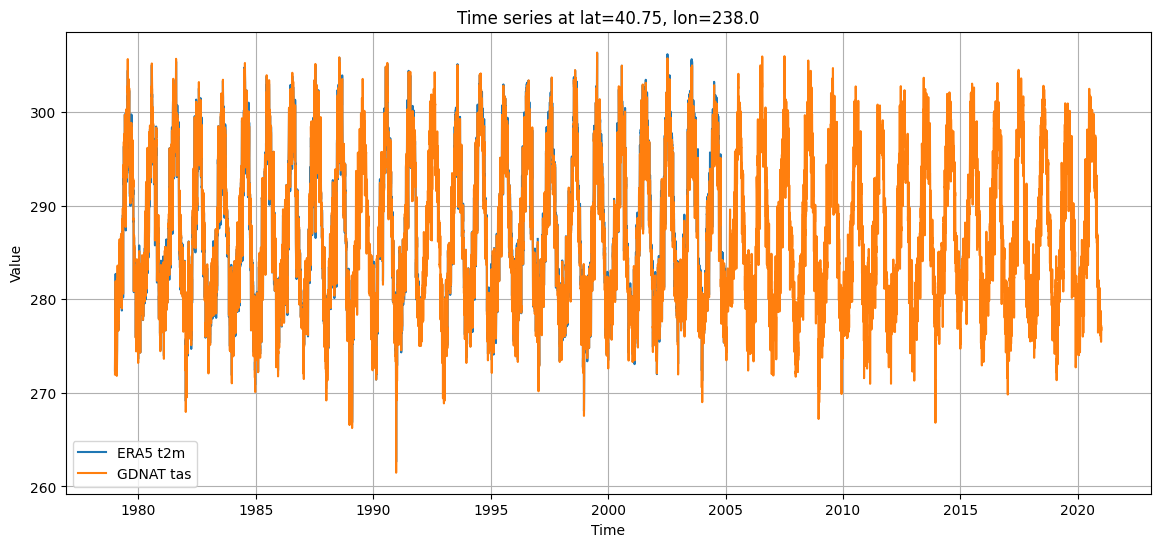

In [5]:


# Exact ERA5 and GDNAT grid coordinates (both on 0-360 lon)
ERA5_LAT = 40.75
ERA5_LON = 238.0
GDNAT_LAT = ERA5_LAT
GDNAT_LON = ERA5_LON

print("LOADING ERA5")
# --- Load ERA5 data ---
years = range(1979, 2005)
era5_datasets = []
for year in years:
    path = config.get_era5_daily_yearly(year)
    ds = xr.open_dataset(path, engine="netcdf4")
    ds_sel = ds.sel(latitude=ERA5_LAT, longitude=ERA5_LON)
    ds_sel = ds_sel.expand_dims(year=[year])
    era5_datasets.append(ds_sel)

ds_era5 = xr.concat(era5_datasets, dim="year")
era5_var = list(ds_era5.data_vars)[0]
df_era5 = ds_era5[era5_var].to_dataframe().reset_index()

print("LOADING GDNAT)")
# --- Load GDNAT data ---
gdnat_files = [
    config.GDNAT_ZARR_1979_1999_FP,
    config.GDNAT_ZARR_PATH_2000_2020_FP,
]

gdnat_datasets = []
for path in gdnat_files:
    ds = xr.open_zarr(path)
    gdnat_var = list(ds.data_vars)[0]
    ds_sel = ds.sel(lat=GDNAT_LAT, lon=GDNAT_LON)
    gdnat_datasets.append(ds_sel)

ds_gdnat = xr.concat(gdnat_datasets, dim="time")
df_gdnat = ds_gdnat[gdnat_var].to_dataframe().reset_index()

print("PLOTTING TIME SERIES)")
# --- Plot both time series ---
plt.figure(figsize=(14, 6))
plt.plot(df_era5['time'], df_era5[era5_var], label=f'ERA5 {era5_var}')
plt.plot(df_gdnat['time'], df_gdnat[gdnat_var], label=f'GDNAT {gdnat_var}')
plt.title(f"Time series at lat={ERA5_LAT}, lon={ERA5_LON}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Exact ERA5 and GDNAT grid coordinates (both on 0-360 lon)
ERA5_LAT = 40.75
ERA5_LON = 238.0
GDNAT_LAT = ERA5_LAT
GDNAT_LON = ERA5_LON

print("LOADING ERA5")
# --- Load ERA5 data ---
years = range(1979, 2005)
era5_datasets = []
for year in years:
    path = config.get_era5_daily_yearly(year)
    ds = xr.open_dataset(path, engine="netcdf4")
    ds_sel = ds.sel(latitude=ERA5_LAT, longitude=ERA5_LON)
    ds_sel = ds_sel.expand_dims(year=[year])
    era5_datasets.append(ds_sel)

ds_era5 = xr.concat(era5_datasets, dim="year")
era5_var = list(ds_era5.data_vars)[0]
df_era5 = ds_era5[era5_var].to_dataframe().reset_index()

print("LOADING GDNAT")
# --- Load GDNAT data ---
gdnat_files = [
    config.GDNAT_ZARR_1979_1999_FP,
    config.GDNAT_ZARR_PATH_2000_2020_FP,
]

gdnat_datasets = []
for path in gdnat_files:
    ds = xr.open_zarr(path)
    gdnat_var = list(ds.data_vars)[0]
    ds_sel = ds.sel(lat=GDNAT_LAT, lon=GDNAT_LON)
    gdnat_datasets.append(ds_sel)

ds_gdnat = xr.concat(gdnat_datasets, dim="time")
df_gdnat = ds_gdnat[gdnat_var].to_dataframe().reset_index()

# --- Aggregate to monthly means ---
df_era5['year'] = df_era5['time'].dt.year
df_era5['month'] = df_era5['time'].dt.month
df_era5_monthly = df_era5.groupby(['year', 'month'])[era5_var].mean().reset_index()
df_era5_monthly['date'] = pd.to_datetime(df_era5_monthly[['year', 'month']].assign(day=1))

df_gdnat['time'] = pd.to_datetime(df_gdnat['time'].astype(str))
df_gdnat['year'] = df_gdnat['time'].dt.year
df_gdnat['month'] = df_gdnat['time'].dt.month

df_gdnat_monthly = df_gdnat.groupby(['year', 'month'])[gdnat_var].mean().reset_index()
df_gdnat_monthly['date'] = pd.to_datetime(df_gdnat_monthly[['year', 'month']].assign(day=1))




LOADING ERA5


/tmp/ipykernel_793730/1902672467.py:17: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path, engine="netcdf4")
/tmp/ipykernel_793730/1902672467.py:17: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path, engine="netcdf4")
/tmp/ipykernel_793730/1902672467.py:17: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path, engine="netcdf4")
/tmp/ipykernel_793730/1902672467.py:17: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To 

LOADING GDNAT


In [7]:
# Convert ERA5 variable from Kelvin to Celsius
df_era5_monthly[era5_var] = df_era5_monthly[era5_var] - 273.15

# Convert GDNAT variable from Kelvin to Celsius
df_gdnat_monthly[gdnat_var] = df_gdnat_monthly[gdnat_var] - 273.15


In [8]:
print(df_era5_monthly.columns)
print(df_gdnat_monthly.columns)


Index(['year', 'month', 't2m', 'date'], dtype='object')
Index(['year', 'month', 'tas', 'date'], dtype='object')


In [32]:
merged = pd.merge(
    df_era5_monthly[['date', 't2m']],
    df_gdnat_monthly[['date', 'tas']],
    on='date',
    how='inner'
)

# Rename columns for clarity
merged = merged.rename(columns={'t2m': 'era5', 'tas': 'gdnat'})

# Calculate difference
merged['diff'] = merged['era5'] - merged['gdnat']


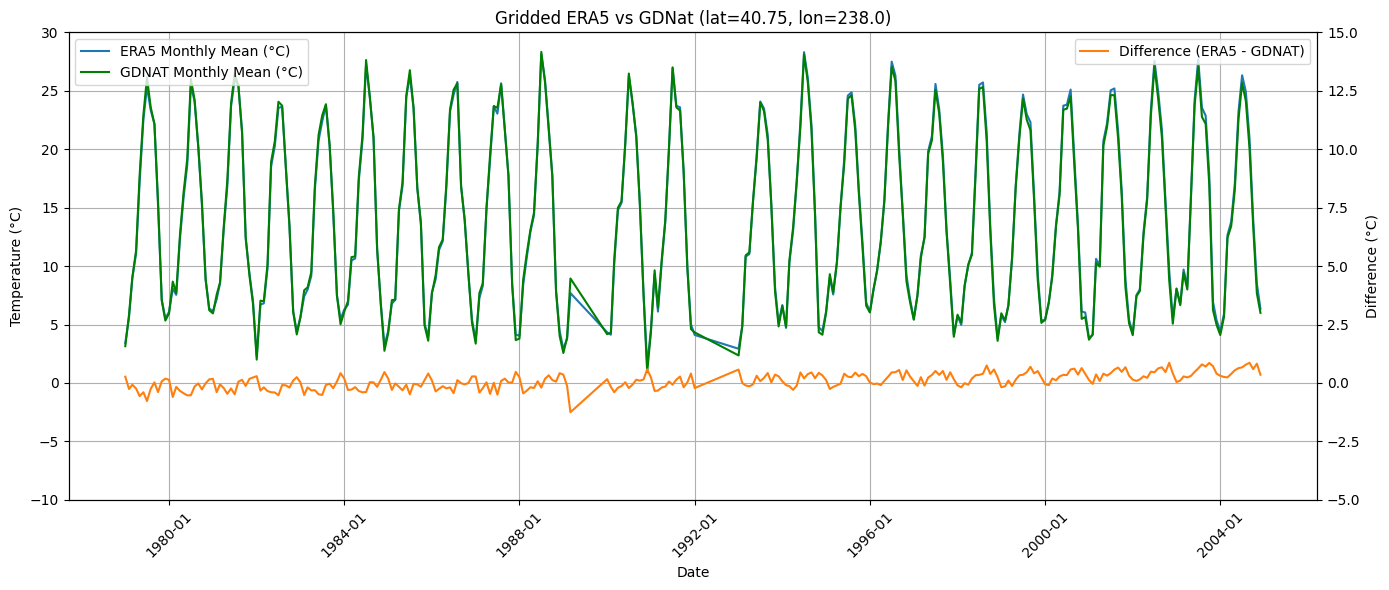

In [33]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(merged['date'], merged['era5'], label='ERA5 Monthly Mean (°C)', color='tab:blue')
ax1.plot(merged['date'], merged['gdnat'], label='GDNAT Monthly Mean (°C)', color='green')

ax1.set_ylabel('Temperature (°C)')
ax1.set_ylim(-10, 30)
ax1.set_xlabel('Date')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='upper left')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(merged['date'], merged['diff'], label='Difference (ERA5 - GDNAT)', color='tab:orange')
ax2.set_ylabel('Difference (°C)')
ax2.set_ylim(-5, 15)
ax2.legend(loc='upper right')

plt.title(f'Gridded ERA5 vs GDNat (lat={ERA5_LAT}, lon={ERA5_LON})')
plt.tight_layout()
plt.show()


/tmp/ipykernel_793730/4090094928.py:21: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ds_all["time"] = xr.decode_cf(ds_all).indexes["time"].to_datetimeindex()  # ← convert time
/tmp/ipykernel_793730/4090094928.py:21: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds_all["time"] = xr.decode_cf(ds_all).indexes["time"].to_datetimeindex()  # ← convert time


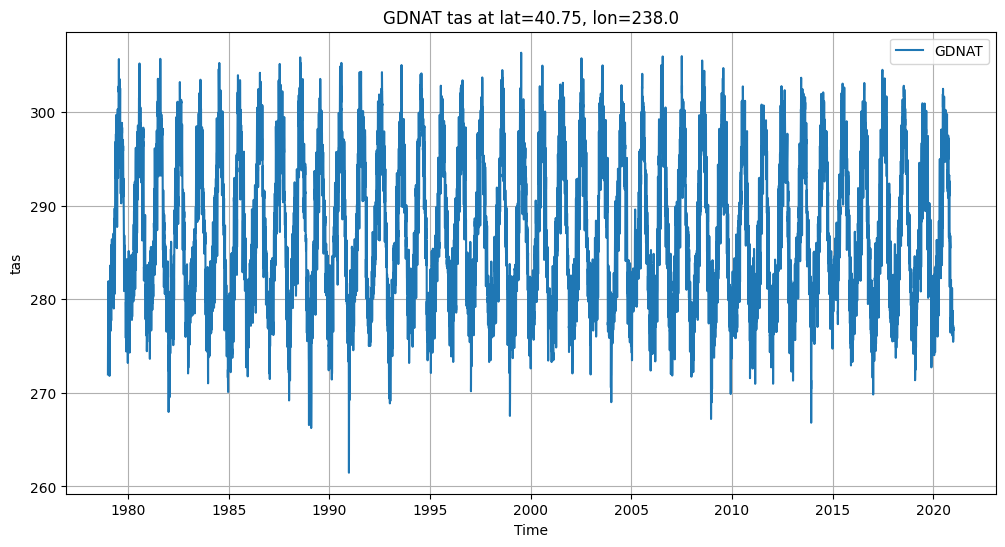

In [12]:


# Coordinates of the exact grid cell
LAT = 40.75
LON = 238.0  # GDNAT also uses 0–360

# File paths from your config
gdnat_files = [
    config.GDNAT_ZARR_1979_1999_FP,
    config.GDNAT_ZARR_PATH_2000_2020_FP,
]

# Load and extract the time series at the grid cell
ds_list = []
for path in gdnat_files:
    ds = xr.open_zarr(path)
    var = list(ds.data_vars)[0]  # assume first variable is tas
    ds_cell = ds.sel(lat=LAT, lon=LON)  # no method="nearest"
    ds_list.append(ds_cell)

# Combine along time dimension
ds_all = xr.concat(ds_list, dim="time")
ds_all["time"] = xr.decode_cf(ds_all).indexes["time"].to_datetimeindex()  # ← convert time
df = ds_all[var].to_dataframe().reset_index()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df["time"], df[var], label="GDNAT")
plt.title(f"GDNAT {var} at lat={LAT}, lon={LON}")
plt.xlabel("Time")
plt.ylabel(var)
plt.grid(True)
plt.legend()
plt.show()


/tmp/ipykernel_793730/1532057504.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  gdnat_agg_df = pd.read_csv(config.GDNAT_COUNTY_FP)


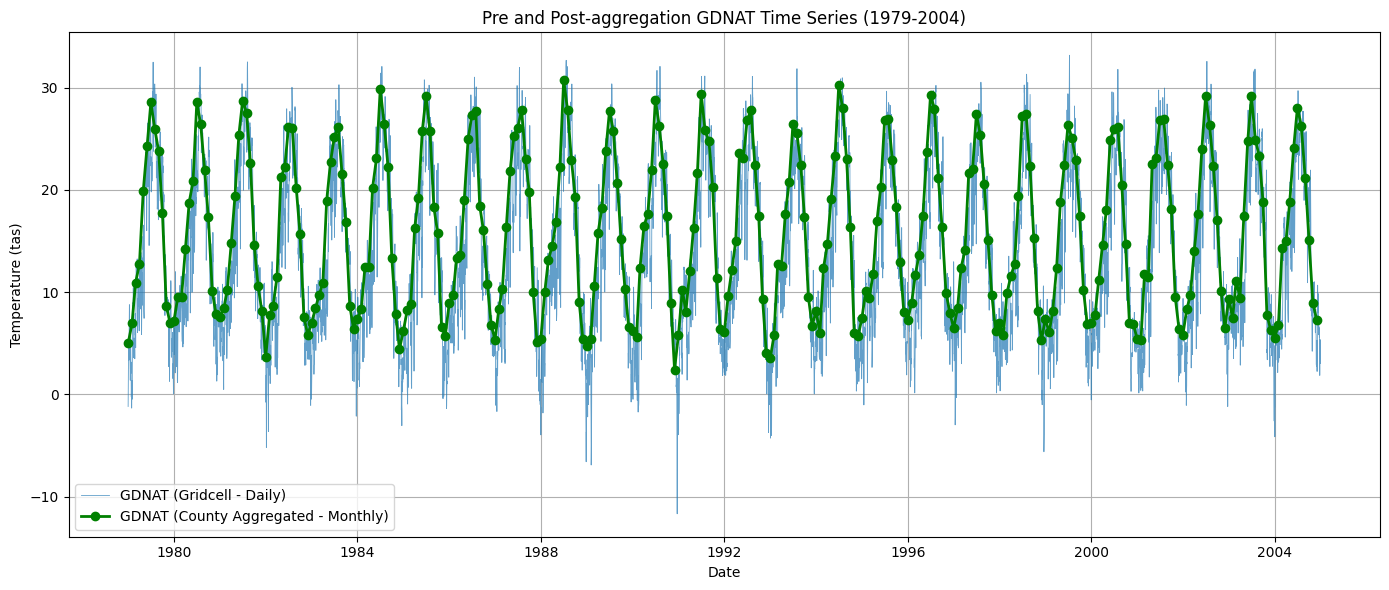

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# === Step 1: Load county-level monthly GDNAT ===
gdnat_agg_df = pd.read_csv(config.GDNAT_COUNTY_FP)

gdnat_6089 = gdnat_agg_df[
    (gdnat_agg_df["poly_id"] == 6089) &
    (gdnat_agg_df["year"] >= 1979) &
    (gdnat_agg_df["year"] <= 2004)
].copy()

gdnat_6089["order_1_avg"] = gdnat_6089["order_1"] / 30
gdnat_6089["date"] = pd.to_datetime(gdnat_6089[["year", "month"]].assign(day=1))
gdnat_6089 = gdnat_6089.drop_duplicates(subset="date", keep="first").reset_index(drop=True)


# === Step 2: Prepare Zarr gridcell daily data ===
df["date"] = pd.to_datetime(df["time"])  # Already daily
df[var] = df[var] - 273.15  # Convert Kelvin to Celsius
df["date"] = pd.to_datetime(df["time"])  # ensure datetime
df = df[(df["date"].dt.year >= 1979) & (df["date"].dt.year <= 2004)].copy()


# var is the variable name (likely "tas")

# === Step 3: Plot ===
fig, ax = plt.subplots(figsize=(14, 6))

# Plot daily gridcell values
ax.plot(
    df["date"],
    df[var],
    label="GDNAT (Gridcell - Daily)",
    color="tab:blue",
    linewidth=0.6,
    alpha=0.7
)

# Plot monthly county-aggregated values
ax.plot(
    gdnat_6089["date"],
    gdnat_6089["order_1_avg"],
    label="GDNAT (County Aggregated - Monthly)",
    color="green",
    marker="o",
    linewidth=2
)

# Formatting
ax.set_title("Pre and Post-aggregation GDNAT Time Series (1979-2004)")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (tas)")
ax.legend()
ax.grid(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()


In [28]:
gdnat_6089_filtered = gdnat_6089[
    (gdnat_6089["date"].dt.year >= 2002) &
    (gdnat_6089["date"].dt.year <= 2004)
].copy()

In [29]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(gdnat_6089_filtered)

         year  month poly_id     order_1       order_2        order_3  \
891852   2002    1.0    6089  175.556043   1328.110985   10302.467903   
891853   2002    2.0    6089  249.915829   2499.942146   26641.158373   
891854   2002    3.0    6089  290.160295   3174.817670   38694.368164   
891855   2002    4.0    6089  420.600120   6443.589465  104480.467222   
891856   2002    5.0    6089  530.048370   9628.538728  183384.722177   
891857   2002    6.0    6089  720.482993  17613.803786  436969.896581   
891858   2002    7.0    6089  875.337537  24921.924308  715156.796288   
891859   2002    8.0    6089  790.276420  20518.726183  541580.665074   
891860   2002    9.0    6089  669.774339  15339.830987  358809.456236   
891861   2002   10.0    6089  511.286968   8902.227232  162404.007288   
891862   2002   11.0    6089  302.963792   3186.065349   34396.378669   
891863   2002   12.0    6089  195.690657   1466.303069   11719.514063   
2497536  2002    1.0    6089  175.556043   1328.110

In [30]:
# 1. Sort by date and reset index
gdnat_6089 = gdnat_6089.sort_values("date").reset_index(drop=True)

# 2. Check for duplicated dates
dupes = gdnat_6089[gdnat_6089.duplicated(subset="date", keep=False)]
print("Duplicates:\n", dupes)

# 3. Check for missing or NaN in 'order_1_avg'
missing = gdnat_6089[gdnat_6089["order_1_avg"].isna()]
print("Missing values:\n", missing)

# 4. Print the dates around the jump (end 1983, start 2004)
print(gdnat_6089[(gdnat_6089["date"] >= "1983-11-01") & (gdnat_6089["date"] <= "1984-01-01")])
print(gdnat_6089[(gdnat_6089["date"] >= "2003-12-01") & (gdnat_6089["date"] <= "2004-02-01")])


Duplicates:
      year  month poly_id     order_1      order_2        order_3  \
36   1982    1.0    6089  110.599698   725.634759    4226.833988   
37   1982    1.0    6089  110.599698   725.634759    4226.833988   
38   1982    2.0    6089  233.532451  2312.293573   24825.790987   
39   1982    2.0    6089  233.532451  2312.293573   24825.790987   
40   1982    3.0    6089  259.630105  2450.959131   24483.771141   
..    ...    ...     ...         ...          ...            ...   
535  2002   10.0    6089  511.286968  8902.227232  162404.007288   
536  2002   11.0    6089  302.963792  3186.065349   34396.378669   
537  2002   11.0    6089  302.963792  3186.065349   34396.378669   
538  2002   12.0    6089  195.690657  1466.303069   11719.514063   
539  2002   12.0    6089  195.690657  1466.303069   11719.514063   

          order_4  order_1_avg       date  
36   3.267126e+04     3.686657 1982-01-01  
37   3.267126e+04     3.686657 1982-01-01  
38   2.879494e+05     7.784415 1982-02

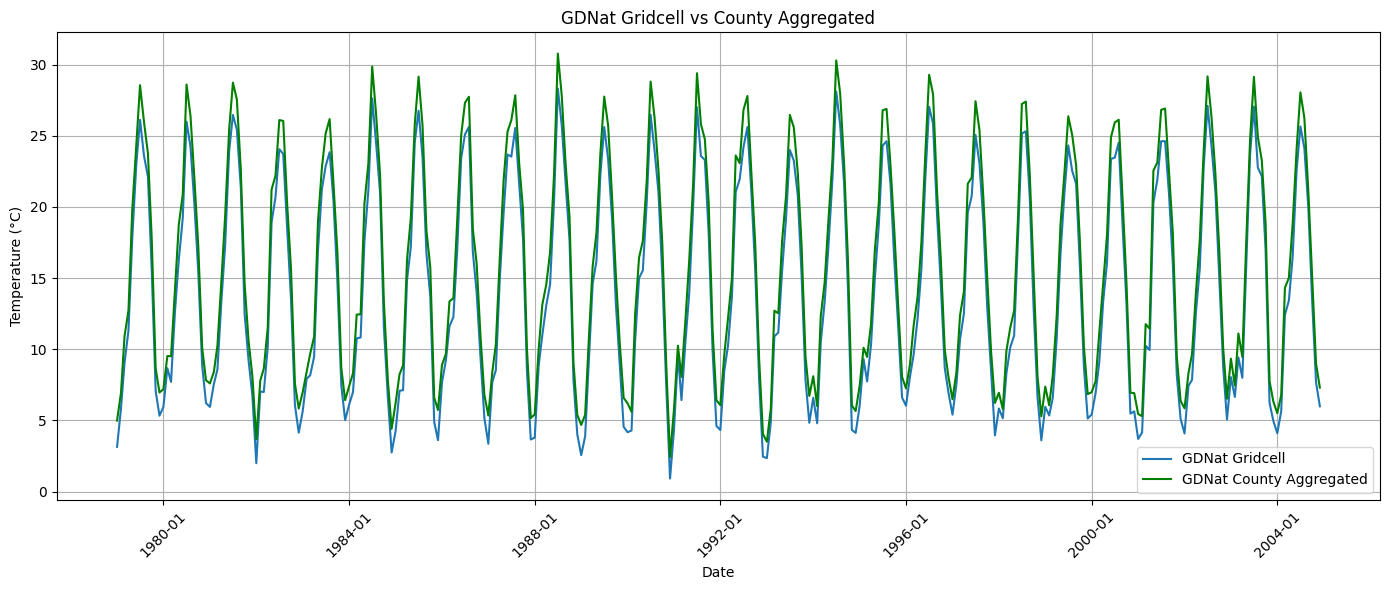

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Assuming df has columns: 'time' (datetime64) and variable var (e.g., temperature)

# 1. Aggregate daily gridcell data to monthly means
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month

df_monthly = (
    df.groupby(['year', 'month'])[var]
      .mean()
      .reset_index()
)

df_monthly['date'] = pd.to_datetime(df_monthly[['year', 'month']].assign(day=1))

# 2. Prepare county aggregated data (make sure filtered to same years/months)
county_monthly = gdnat_6089.copy()  # already has 'date' column and 'order_1_avg'

# 3. Plot together
plt.figure(figsize=(14,6))

plt.plot(df_monthly['date'], df_monthly[var], label='GDNat Gridcell', color='tab:blue')
plt.plot(county_monthly['date'], county_monthly['order_1_avg'], label='GDNat County Aggregated', color='green')

plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('GDNat Gridcell vs County Aggregated')
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


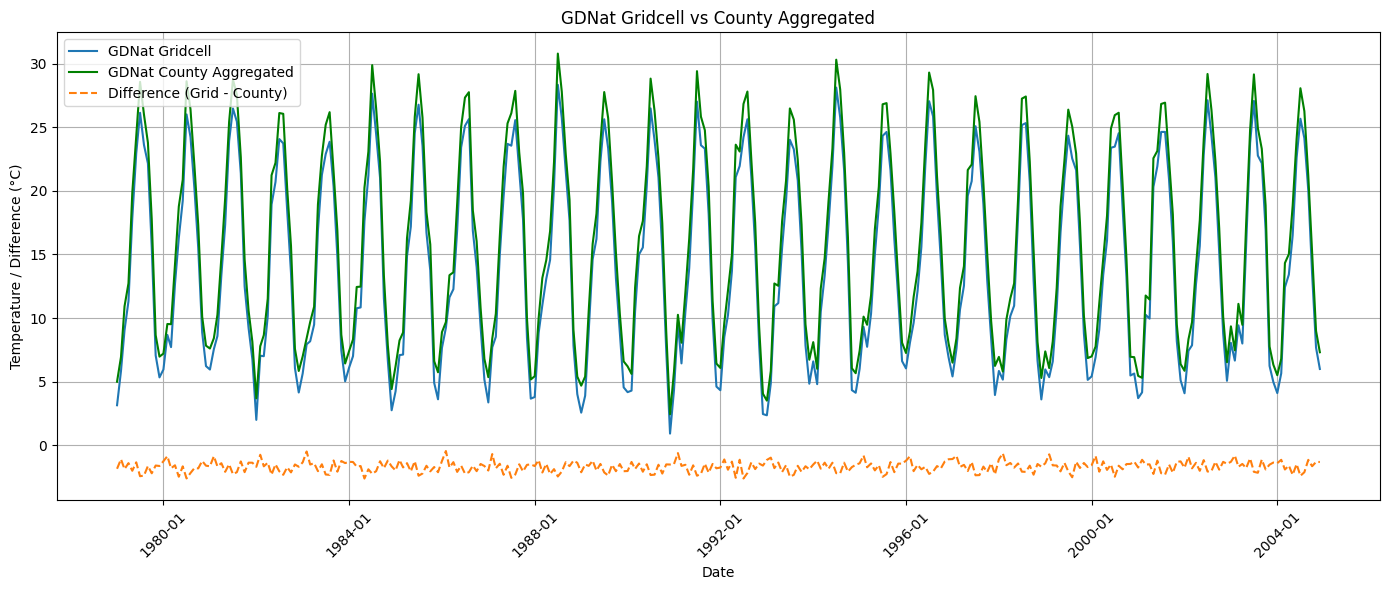

In [30]:


# 1. Aggregate daily gridcell data to monthly means
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month

df_monthly = (
    df.groupby(['year', 'month'])[var]
      .mean()
      .reset_index()
)

df_monthly['date'] = pd.to_datetime(df_monthly[['year', 'month']].assign(day=1))

# 2. Prepare county aggregated data (already has 'date' and 'order_1_avg')
county_monthly = gdnat_6089.copy()

# 3. Merge for diff calculation
merged = pd.merge(
    df_monthly[['date', var]],
    county_monthly[['date', 'order_1_avg']],
    on='date',
    how='inner'
)

merged['diff'] = merged[var] - merged['order_1_avg']

# 4. Plot all on same axis
plt.figure(figsize=(14, 6))

plt.plot(merged['date'], merged[var], label='GDNat Gridcell', color='tab:blue')
plt.plot(merged['date'], merged['order_1_avg'], label='GDNat County Aggregated', color='green')
plt.plot(merged['date'], merged['diff'], label='Difference (Grid - County)', color='tab:orange', linestyle='--')

plt.xlabel('Date')
plt.ylabel('Temperature / Difference (°C)')
plt.title('GDNat Gridcell vs County Aggregated')
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
import os
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Config import assumed done already
# from config import get_era5_daily_yearly, ERA5_DAILY_FOLDER, ERA5_COUNTY_AGG_FILEPATH

# Exact ERA5 grid cell for Shasta county (0-360 lon)
ERA5_LAT = 40.75
ERA5_LON = 238.0

# --- Load ERA5 daily gridded data for years 1979-2004 ---
years = range(1979, 2005)
era5_dfs = []

for year in years:
    path = config.get_era5_daily_yearly(year)
    ds = xr.open_dataset(path, engine="netcdf4")
    # Select exact grid cell - assume coords are named 'latitude' and 'longitude' or 'lat' and 'lon'
    # Adjust names below if needed
    if 'latitude' in ds.coords and 'longitude' in ds.coords:
        ds_sel = ds.sel(latitude=ERA5_LAT, longitude=ERA5_LON)
    else:
        ds_sel = ds.sel(lat=ERA5_LAT, lon=ERA5_LON)
    
    varname = list(ds_sel.data_vars)[0]  # Assume first variable is temperature
    df_tmp = ds_sel[varname].to_dataframe().reset_index()
    era5_dfs.append(df_tmp)

# Concatenate all years
df_era5_daily = pd.concat(era5_dfs, ignore_index=True)

# Convert temperature from Kelvin to Celsius (assuming Kelvin)
df_era5_daily[varname] = df_era5_daily[varname] - 273.15

# Aggregate to monthly means
df_era5_daily['year'] = df_era5_daily['time'].dt.year
df_era5_daily['month'] = df_era5_daily['time'].dt.month
df_era5_monthly = df_era5_daily.groupby(['year', 'month'])[varname].mean().reset_index()
df_era5_monthly['date'] = pd.to_datetime(df_era5_monthly[['year', 'month']].assign(day=1))


/tmp/ipykernel_793730/1536976812.py:20: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path, engine="netcdf4")
/tmp/ipykernel_793730/1536976812.py:20: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path, engine="netcdf4")
/tmp/ipykernel_793730/1536976812.py:20: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path, engine="netcdf4")
/tmp/ipykernel_793730/1536976812.py:20: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To 

KeyError: 'adm2_id'

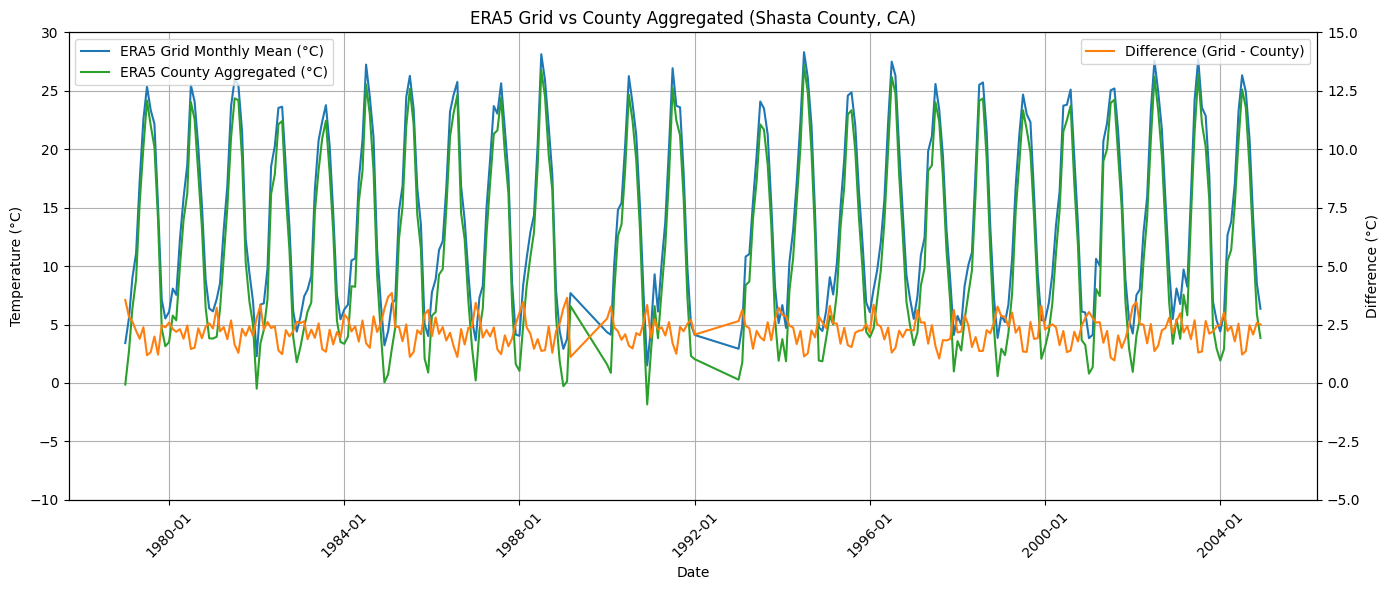

In [28]:

# --- Load county aggregated ERA5 data for Shasta ---
era5_county_df = pd.read_csv(config.ERA5_COUNTY_AREA_FP)

era5_shasta = era5_county_df[
    (era5_county_df['poly_id'] == 6089) &
    (era5_county_df['year'] >= 1979) &
    (era5_county_df['year'] <= 2004)
].copy()

# Select appropriate ERA5 county temperature variable (update as needed)
county_temp_var = 'order_1_avg'  # Change to your variable name

# Extract numeric month from 'month' column like 'month_01' → 1
era5_shasta['month'] = era5_shasta['month'].str.extract(r'(\d+)').astype(int)

# Then create the date column
era5_shasta['date'] = pd.to_datetime(dict(year=era5_shasta.year, month=era5_shasta.month, day=1))

era5_shasta["order_1_avg"] = era5_shasta["order_1"] / 30

# --- Merge monthly gridded and county aggregated ---
merged_era5 = pd.merge(
    df_era5_monthly[['date', varname]],
    era5_shasta[['date', county_temp_var]],
    on='date',
    how='inner'
)

merged_era5 = merged_era5.rename(columns={varname: 'era5_grid', county_temp_var: 'era5_county'})
merged_era5['diff'] = merged_era5['era5_grid'] - merged_era5['era5_county']

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(merged_era5['date'], merged_era5['era5_grid'], label='ERA5 Grid Monthly Mean (°C)', color='tab:blue')
ax1.plot(merged_era5['date'], merged_era5['era5_county'], label='ERA5 County Aggregated (°C)', color='tab:green')

ax1.set_ylabel('Temperature (°C)')
ax1.set_ylim(-10, 30)
ax1.set_xlabel('Date')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='upper left')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(merged_era5['date'], merged_era5['diff'], label='Difference (Grid - County)', color='tab:orange')
ax2.set_ylabel('Difference (°C)')
ax2.set_ylim(-5, 15)
ax2.legend(loc='upper right')

plt.title('ERA5 Grid vs County Aggregated (Shasta County, CA)')
plt.tight_layout()
plt.show()


In [27]:
merged_era5

,date,era5_grid,era5_county,diff
0,1979-01-01,3.411779,-0.137880,3.549659
1,1979-02-01,5.575317,2.753799,2.821519
2,1979-03-01,8.974314,6.343503,2.630810
3,1979-04-01,11.083194,8.853855,2.229339
4,1979-05-01,17.276091,15.385097,1.890994
...,...,...,...,...
287,2004-08-01,24.919264,23.563128,1.356136
288,2004-09-01,20.869572,18.401687,2.467884
289,2004-10-01,14.065514,11.996457,2.069057
290,2004-11-01,8.492167,5.915488,2.576679


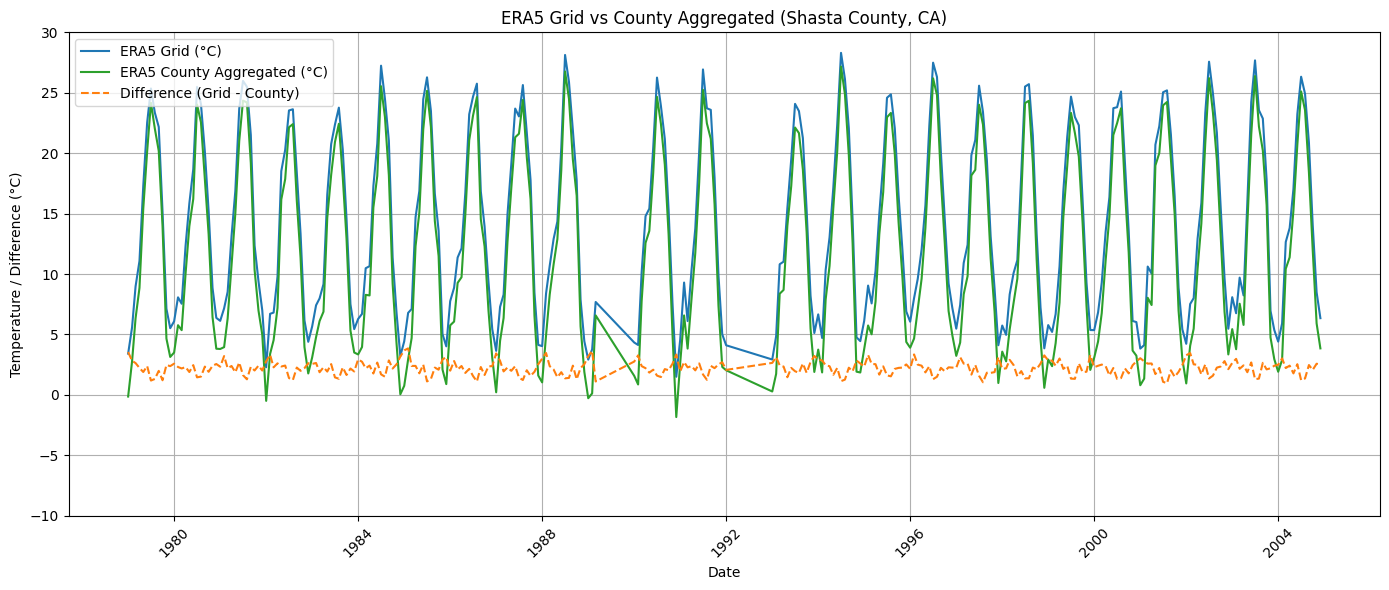

In [29]:
# --- Load county aggregated ERA5 data for Shasta ---
era5_county_df = pd.read_csv(config.ERA5_COUNTY_AREA_FP)

era5_shasta = era5_county_df[
    (era5_county_df['poly_id'] == 6089) &
    (era5_county_df['year'] >= 1979) &
    (era5_county_df['year'] <= 2004)
].copy()

# Prepare variables
county_temp_var = 'order_1_avg'
era5_shasta['month'] = era5_shasta['month'].str.extract(r'(\d+)').astype(int)
era5_shasta['date'] = pd.to_datetime(dict(year=era5_shasta.year, month=era5_shasta.month, day=1))
era5_shasta['order_1_avg'] = era5_shasta['order_1'] / 30  # Convert from Kelvin to Celsius

# --- Merge gridded and county-level ERA5 ---
merged_era5 = pd.merge(
    df_era5_monthly[['date', varname]],
    era5_shasta[['date', county_temp_var]],
    on='date',
    how='inner'
)

merged_era5 = merged_era5.rename(columns={varname: 'era5_grid', county_temp_var: 'era5_county'})
merged_era5['diff'] = merged_era5['era5_grid'] - merged_era5['era5_county']

# --- Plot all on one y-axis ---
plt.figure(figsize=(14, 6))
plt.plot(merged_era5['date'], merged_era5['era5_grid'], label='ERA5 Grid (°C)', color='tab:blue')
plt.plot(merged_era5['date'], merged_era5['era5_county'], label='ERA5 County Aggregated (°C)', color='tab:green')
plt.plot(merged_era5['date'], merged_era5['diff'], label='Difference (Grid - County)', color='tab:orange', linestyle='--')

plt.ylabel('Temperature / Difference (°C)')
plt.xlabel('Date')
plt.title('ERA5 Grid vs County Aggregated (Shasta County, CA)')
plt.ylim(-10, 30)
plt.legend(loc='upper left')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
